<a href="https://colab.research.google.com/github/MikhaelVinicius/Deteccao_de_Patologias_Asfalticas_com_IA/blob/main/Detec%C3%A7%C3%A3oDeBuracos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

!pip install ultralytics
import ultralytics
ultralytics.checks()

Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 43.3/112.6 GB disk)


In [ ]:

!pip install roboflow
from roboflow import Roboflow


rf = Roboflow(api_key="ClpMNyfY1geF7Q71Hnm3")
project = rf.workspace("smartathon").project("new-pothole-detection")
version = project.version(1)
dataset = version.download("yolov8")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to New-pothole-detection-1 in yolov8:: 100%|██████████| 18492/18492 [00:02<00:00, 6382.66it/s]


In [ ]:

from ultralytics import YOLO


model = YOLO('yolov8n.pt')

results = model.train(data=f'{dataset.location}/data.yaml', epochs=50, imgsz=640)

Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/New-pothole-detection-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, 

In [ ]:

model.export(format='tflite', int8=True)

Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
WARNING ⚠️ INT8 export requires a missing 'data' arg for calibration. Using default 'data=coco8.yaml'.
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs

PyTorch: starting from '/content/runs/detect/train/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 5, 8400) (6.0 MB)
TensorFlow SavedModel: collecting INT8 calibration images from 'data=coco8.yaml'

WARNING ⚠️ Dataset 'coco8.yaml' images not found, missing path '/content/datasets/coco8/images/val'
Unzipping /content/datasets/coco8.zip to /content/datasets/coco8...: 100% ━━━━━━━━━━━━ 25/25 3.0Kfiles/s 0.0s
Dataset download success ✅ (0.6s), saved to /content/datasets

Fast image access ✅ (ping: 0.0±0.0 ms, read: 1899.2±541.7 MB/s, size: 54.0 KB)
Scann

'/content/runs/detect/train/weights/best_saved_model/best_int8.tflite'


image 1/1 /content/60140f17bc4de.jpg: 448x640 2 Potholes, 44.2ms
Speed: 2.6ms preprocess, 44.2ms inference, 5.6ms postprocess per image at shape (1, 3, 448, 640)


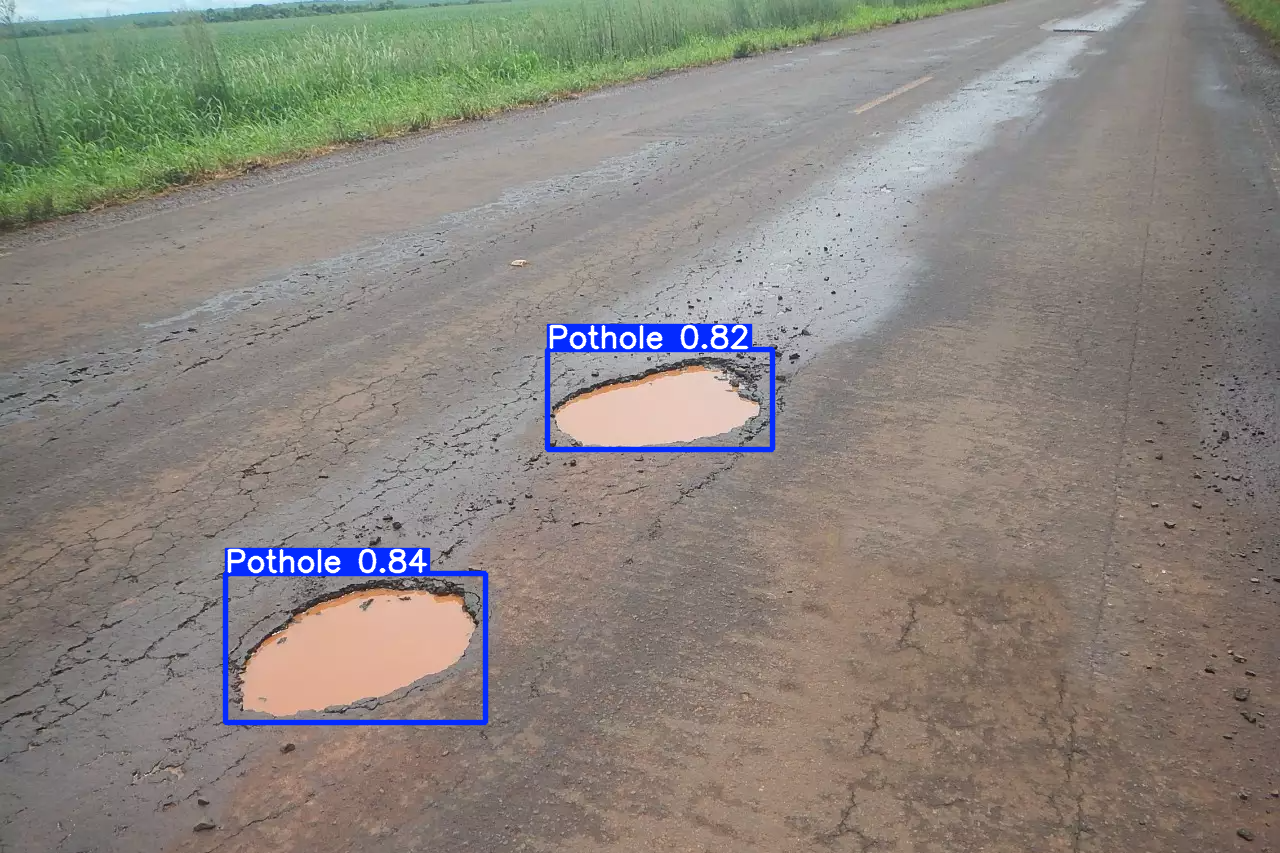

In [ ]:

model = YOLO('/content/runs/detect/train/weights/best.pt')


results = model.predict(source='https://cdn6.campograndenews.com.br/uploads/noticias/2021/01/29/60140f17bc4de.jpg', conf=0.25)

from google.colab.patches import cv2_imshow
import cv2

res_plotted = results[0].plot()
cv2_imshow(res_plotted)